In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-1, tmax=2, resample=None, fmin=0.1, fmax=None)
dataset = BNCI2014009()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.


<RawArray | 18 x 50184 (196.0 s), ~6.9 MB, data loaded>

In [4]:
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,-1.000 – 2.000 sec
Baseline,off


In [5]:
n_freqs = 16
freqs = np.linspace(1,32,n_freqs)
n_cycles = 0.8*freqs
sfreq=64

epochs_tfr = tfr_morlet(
    epochs, freqs, n_cycles, return_itc=False, average=False,
    output='complex', verbose=True, n_jobs=-1,
                        decim=int(epochs.info['sfreq']//sfreq))
#epochs_tfr.data = np.real(epochs_tfr.data)
epochs_tfr.apply_baseline((0,1.2), mode='zscore')
epochs_tfr.crop(0, 1.2)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of  16 | elapsed:    4.3s remaining:    3.3s
[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:    4.9s remaining:    1.1s


Not setting metadata
Applying baseline correction (mode: zscore)


[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:    5.1s finished


<EpochsTFR | time : [0.000000, 1.203125], freq : [1.000000, 32.000000], epochs : 576, channels : 16, ~175.5 MB>

No baseline correction applied


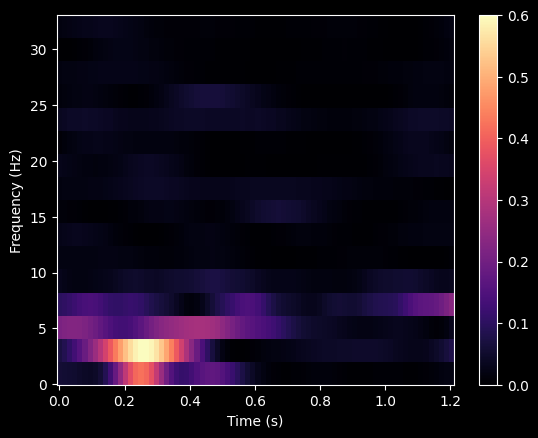

No baseline correction applied


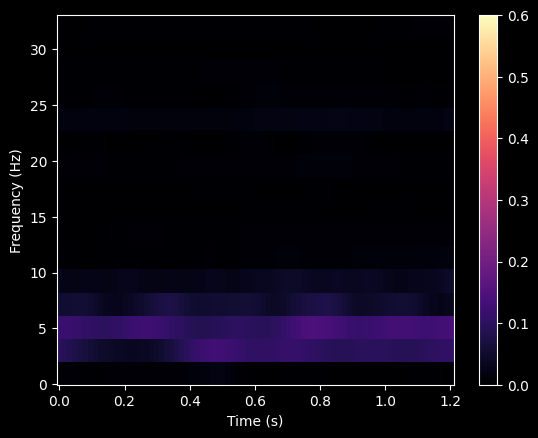

No baseline correction applied


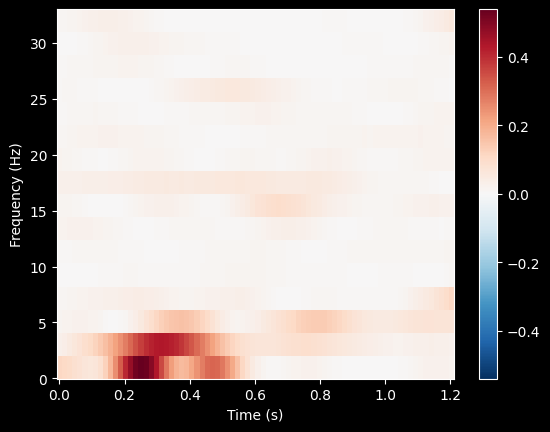

In [12]:
from mne import combine_evoked

plt.style.use('dark_background')


target = epochs_tfr['Target'].average()
non_target = epochs_tfr['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])

vmax = np.max(np.abs(target.data))
tfr_args=dict(picks=['Cz'], vmin=0, vmax=0.6, cmap='magma')

_ = target.plot(**tfr_args)
_ = non_target.plot(**tfr_args)
_ = contrast.plot(picks=['Cz'])


In [23]:
import tensorly as tl
tl.set_backend('cupy')

split = len(epochs)//2
X = tl.tensor(epochs_tfr.data, dtype=np.complex128)
X_train = X[:split]
X_test = X[split:]
y_train = labels[:split]
y_test = labels[split:]

In [42]:
import cupy
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

hoda_lda = Pipeline([
        ('hoda', HODA(
            rank=None,
            max_iter=128,
            tol=1e-4,
            init ='mlsvd',
            verbose=True,
            shrinkage=(0.01,0.01,0.01),
            toeplitz=(2,),
            taper=False,
            solver='diff',
            keep_train_info=True,
        )),
        ('complex',FeatureUnion([
            ('real', FunctionTransformer(np.real)),
            ('imag', FunctionTransformer(np.imag)),
        ])),
        ('lda', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')),
        #('svm', SVC(kernel='rbf', C=1e-3)),
])

hoda_lda.fit(X_train,y_train)

Initializing factors...


  0%|          | 0/128 [00:00<?, ?it/s]

Fit tucker model of rank [4, 3, 66]


Pipeline(steps=[('hoda',
                 HODA(keep_train_info=True, max_iter=128,
                      shrinkage=(0.01, 0.01, 0.01), solver='diff',
                      toeplitz=(2,), tol=0.0001, verbose=True)),
                ('complex',
                 FeatureUnion(transformer_list=[('real',
                                                 FunctionTransformer(func=<function real at 0x7f5c911dcae0>)),
                                                ('imag',
                                                 FunctionTransformer(func=<function imag at 0x7f5c911dccc0>))])),
                ('lda',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])

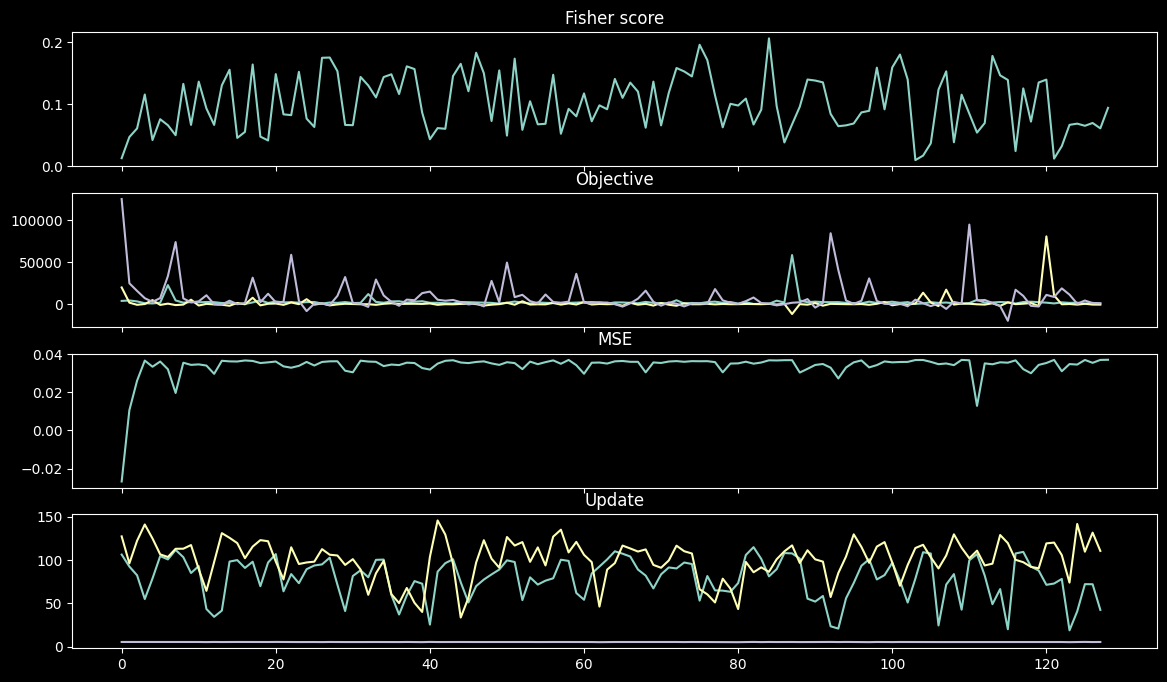

In [43]:
fig, axs = plt.subplots(4,1, sharex=True, figsize=(14,8))

axs[0].set_title('Fisher score')
axs[0].plot(hoda_lda['hoda'].train_info_["f_score"])

axs[1].set_title('Objective')
axs[1].plot(np.asarray(hoda_lda['hoda'].train_info_["mode_objective"]).T)

axs[2].set_title('MSE')
axs[2].plot(hoda_lda['hoda'].train_info_["mse"])

axs[3].set_title('Update')
axs[3].plot(np.asarray(hoda_lda['hoda'].train_info_["mode_update"]).T)


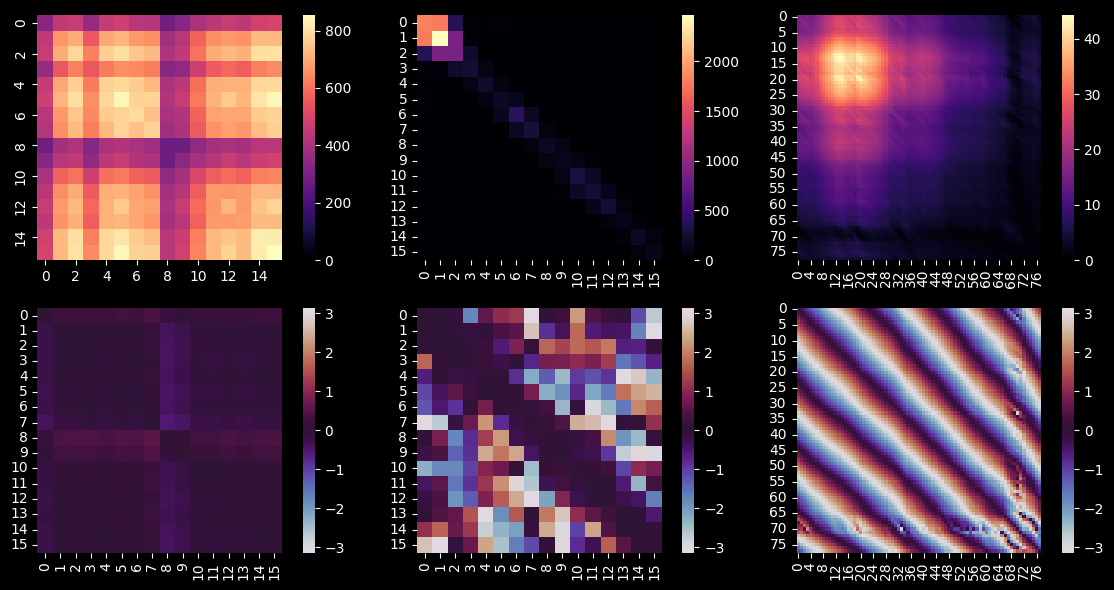

In [44]:
fig, axs = plt.subplots(2,3, layout='tight', figsize=(12,6))
for k in range(3):
    scatter_b = cupy.asnumpy(hoda_lda['hoda'].scatter_b_[k])
    sns.heatmap(np.abs(scatter_b), ax=axs[0,k], cmap='magma', vmin=0)
    axs[0,k].set_aspect('equal')
    sns.heatmap(np.angle(scatter_b), ax=axs[1,k], cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axs[1,k].set_aspect('equal')

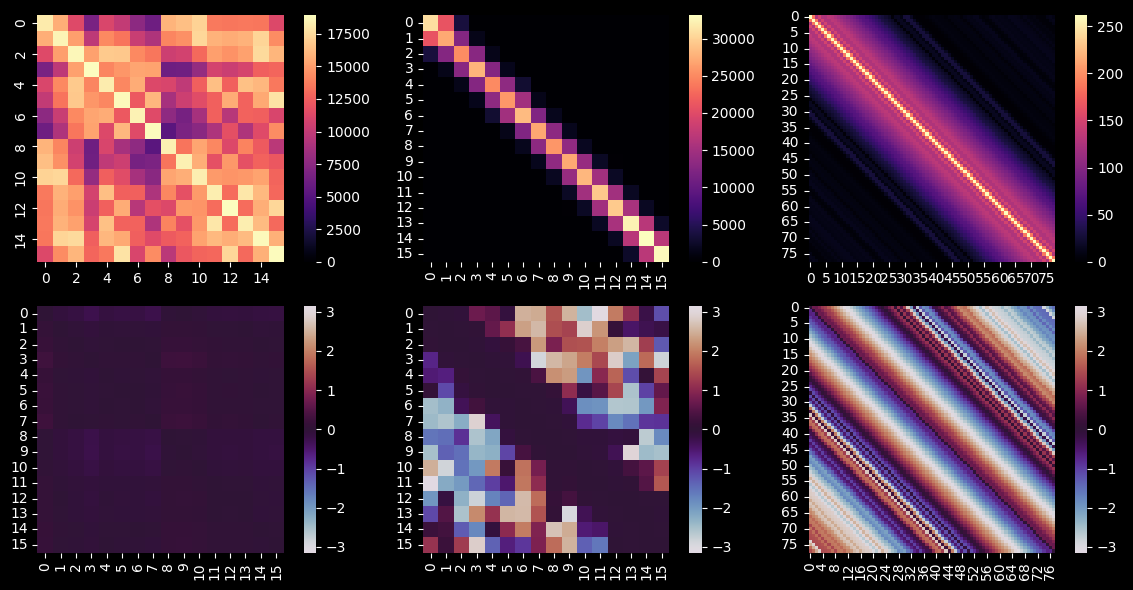

In [45]:
fig, axs = plt.subplots(2,3, layout='tight', figsize=(12,6))
for k in range(3):
    scatter_w = cupy.asnumpy(hoda_lda['hoda'].scatter_w_[k])
    sns.heatmap(np.abs(scatter_w), ax=axs[0,k], cmap='magma', vmin=0)
    axs[0,k].set_aspect('equal')
    sns.heatmap(np.angle(scatter_w), ax=axs[1,k], cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axs[1,k].set_aspect('equal')

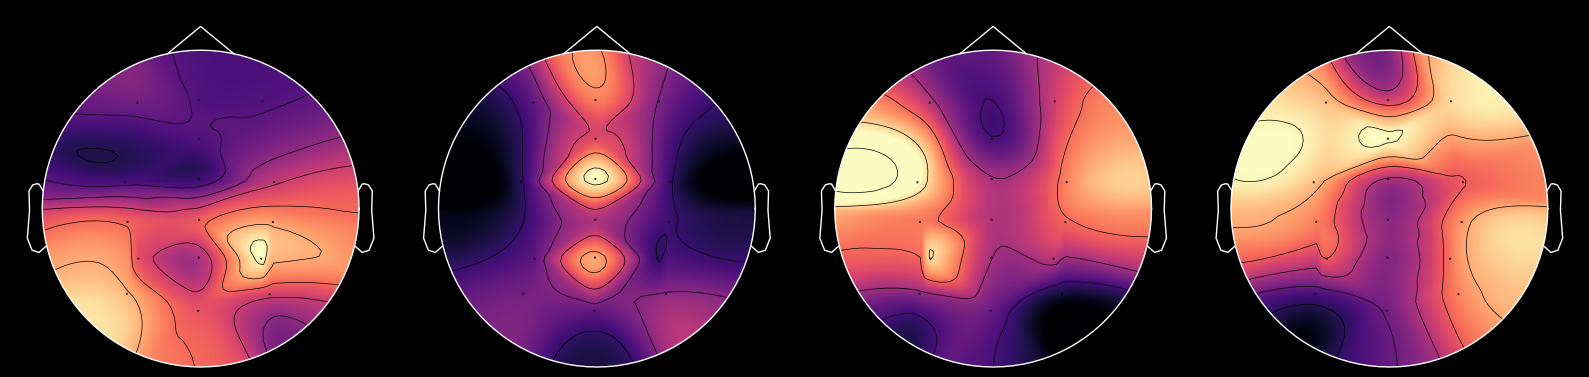

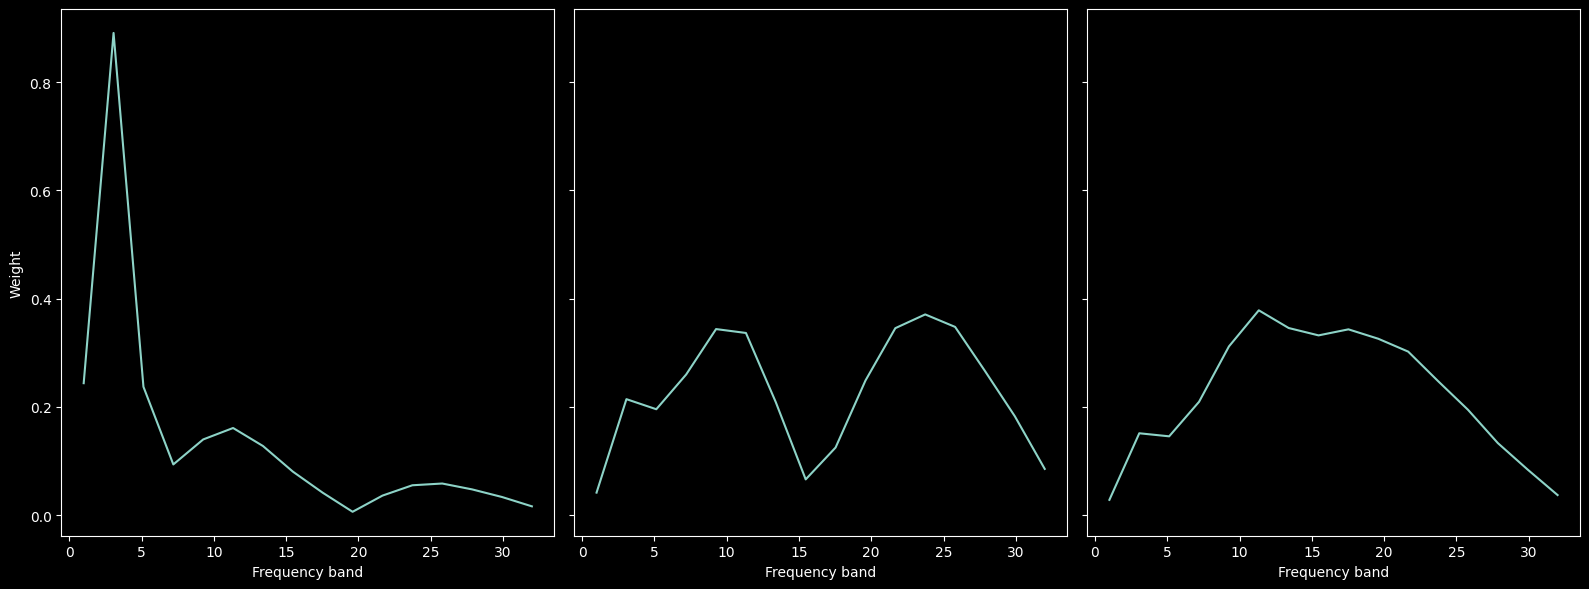

/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


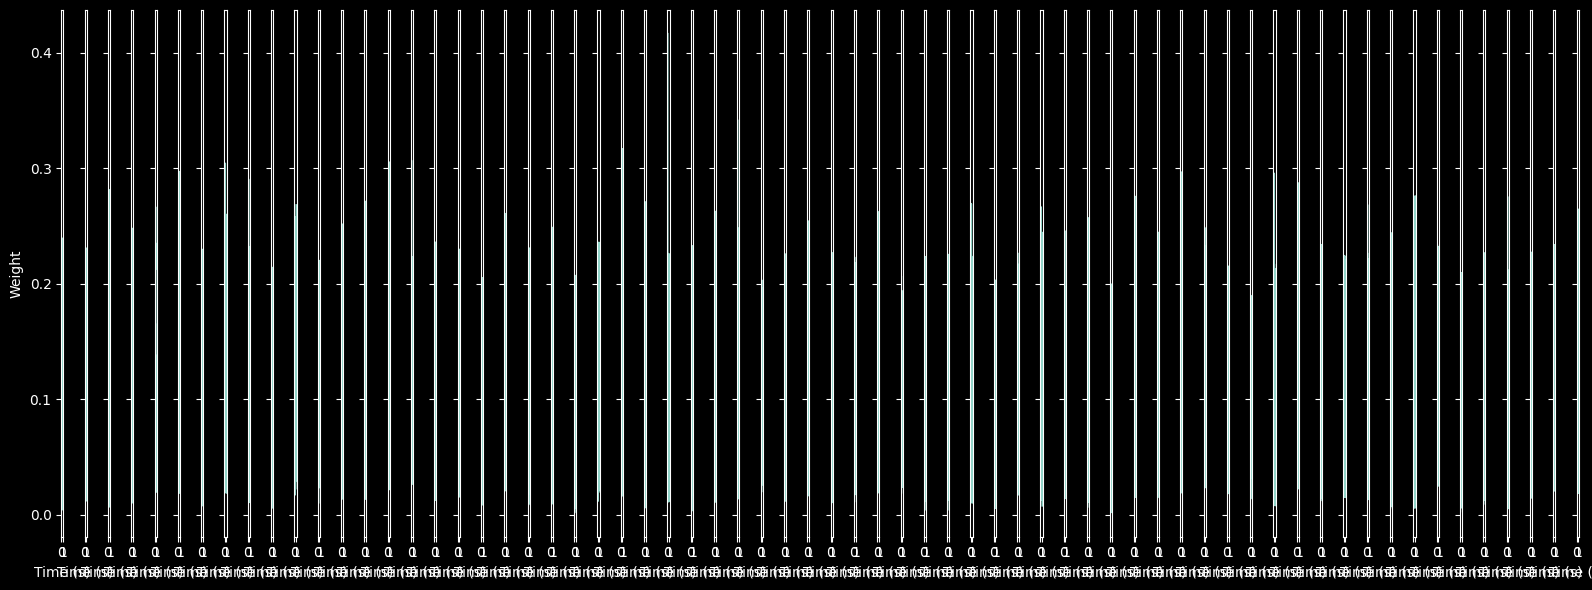

In [46]:
fig, axs = plt.subplots(1,max(hoda_lda['hoda'].rank_[0],2), figsize=(16,6), layout='tight')
for i in range(hoda_lda['hoda'].rank_[0]):
    w = cupy.asnumpy(hoda_lda['hoda'].scalings_[0][:,i])
    plot_topomap(np.abs(w), epochs.info, axes=axs[i], show=False, cmap='magma')

fig, axs = plt.subplots(1,max(hoda_lda['hoda'].rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
for i in range(hoda_lda['hoda'].rank_[1]):
    w = cupy.asnumpy(hoda_lda['hoda'].scalings_[1][:,i])
    axs[i].plot(freqs, np.abs(w))
    axs[i].set_xlabel('Frequency band')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');

fig, axs = plt.subplots(1,max(hoda_lda['hoda'].rank_[2],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
for i in range(hoda_lda['hoda'].rank_[2]):
    w = cupy.asnumpy(hoda_lda['hoda'].scalings_[2][:,i])
    axs[i].plot(epochs_tfr.times, np.abs(w))
    axs[i].set_xlabel('Time (s)')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');

<AxesSubplot: xlabel='score', ylabel='Count'>

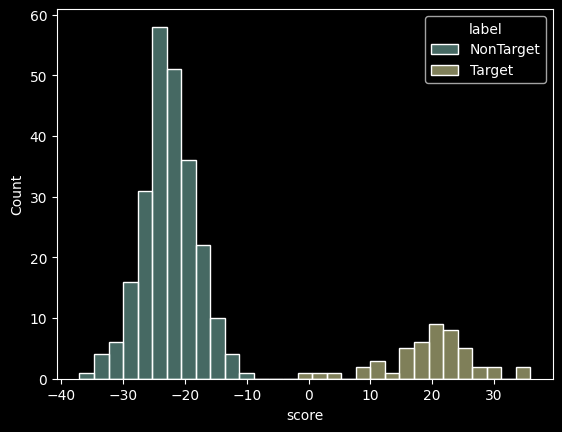

In [47]:
import pandas as pd

train_scores = cupy.asnumpy(hoda_lda.decision_function(X_train))
df = pd.DataFrame(dict(score=cupy.asnumpy(train_scores),label=y_train))
sns.histplot(data=df, x='score', hue='label')

In [48]:
roc_auc_score(y_train,train_scores)

1.0

<AxesSubplot: xlabel='score', ylabel='Count'>

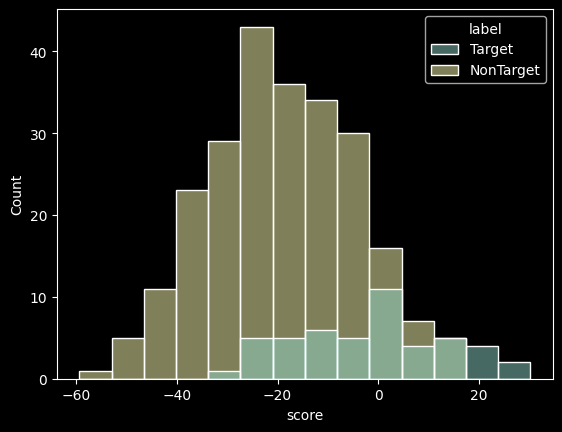

In [49]:
import pandas as pd

test_scores = cupy.asnumpy(hoda_lda.decision_function(X_test))
df = pd.DataFrame(dict(score=cupy.asnumpy(test_scores),label=y_test))
sns.histplot(data=df, x='score', hue='label')

In [50]:
roc_auc_score(y_test,test_scores)

0.7899305555555556